In [14]:
from pathlib import Path
import sys
import numpy as np

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))

from docs.plot_setup import set_professional_style
plt = set_professional_style()

from SysSimX.components.fmu_comp import FMUComponent

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from MyModels.FEM.fem_pendulum import FEMPendulum
import MyModels.FEM.pendulum_config as fem_config
from MyModels.OpenSim.opensim_pendulum import OpenSimPendulum
from MyModels.MasterPendulum.master_pendulum import MasterPendulum
from MyModels.MasterPendulum.pendulum_ode import PendulumODE, zero_torque

In [15]:
# FMU Pendulum
fmu_pendulum_path = Path.cwd().parent / 'FMUs/Pendulum.fmu'
eqb_pendulum     = FMUComponent(name="EQB_Pendulum", fmu_path=fmu_pendulum_path)

# OpenSim Pendulum
opensim_pendulum = OpenSimPendulum(name="OpenSim_Pendulum")

# FEM Pendulum with master configuration
fem_pendulum     = FEMPendulum(name="FEM_Pendulum")
init_params = fem_config.InitialConditionParameters()
init_params.angular_position_deg = 20  # degrees
init_params.drive_torque = 0  # Nm

q0 = np.deg2rad(init_params.angular_position_deg)
omega0 = init_params.angular_velocity

sim_params = fem_config.SimulationParameters()
sim_params.tau = 0.001
sim_params.t_end = 3.0
sim_params.with_contact = False
sim_params.use_gravity = True

animation_params = fem_config.AnimationParameters()
animation_params.animate = False

fem_pendulum.set_parameters(init_params=init_params,
                            sim_params=sim_params,
                            anim_params=animation_params)

pendulum = MasterPendulum(
    fem_comp=fem_pendulum,
    opensim_comp=opensim_pendulum,
    fmu_comp=eqb_pendulum
)

t = 0.0
dt = fem_pendulum.sim_params.tau
t_end = fem_pendulum.sim_params.t_end

pendulum.initialize(t)
pendulum.setup_monitoring()
pendulum.display_monitoring()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [16]:
# Analytical Solution using ODE Pendulum
pendulum_ode = PendulumODE(mass=fem_pendulum.mass,
                           length=fem_pendulum._equivalent_length,
                           inertia=fem_pendulum.inertia,
                           g= 9.81 if fem_pendulum.sim_params.use_gravity else 0.0)

torque_amp = init_params.drive_torque
t_an_vals, q_an_vals, omega_an_vals, alpha_an_vals = pendulum_ode.solve(t_span=(0.0, t_end),
                                                    y0=[np.deg2rad(init_params.angular_position_deg), 0.0],
                                                    torque_func=zero_torque,
                                                    dt=dt)

In [17]:
torque_func: callable = zero_torque

while t < t_end:
    # 1) Compute input torque
    torque = torque_func(t)
    
    # 2) Perform simulation step
    pendulum.set_inputs({'torque': torque}, t=t)

    # 3) Integrate one time step
    pendulum.do_step(t, dt)

    # 4) Advance time
    t += dt

[Pendulum] Switching: EQB to OpenSim @ t=0.0500s
[Pendulum] Switching: OpenSim to FEM @ t=0.2500s
[Pendulum] Switching: FEM to EQB @ t=0.5000s
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVE

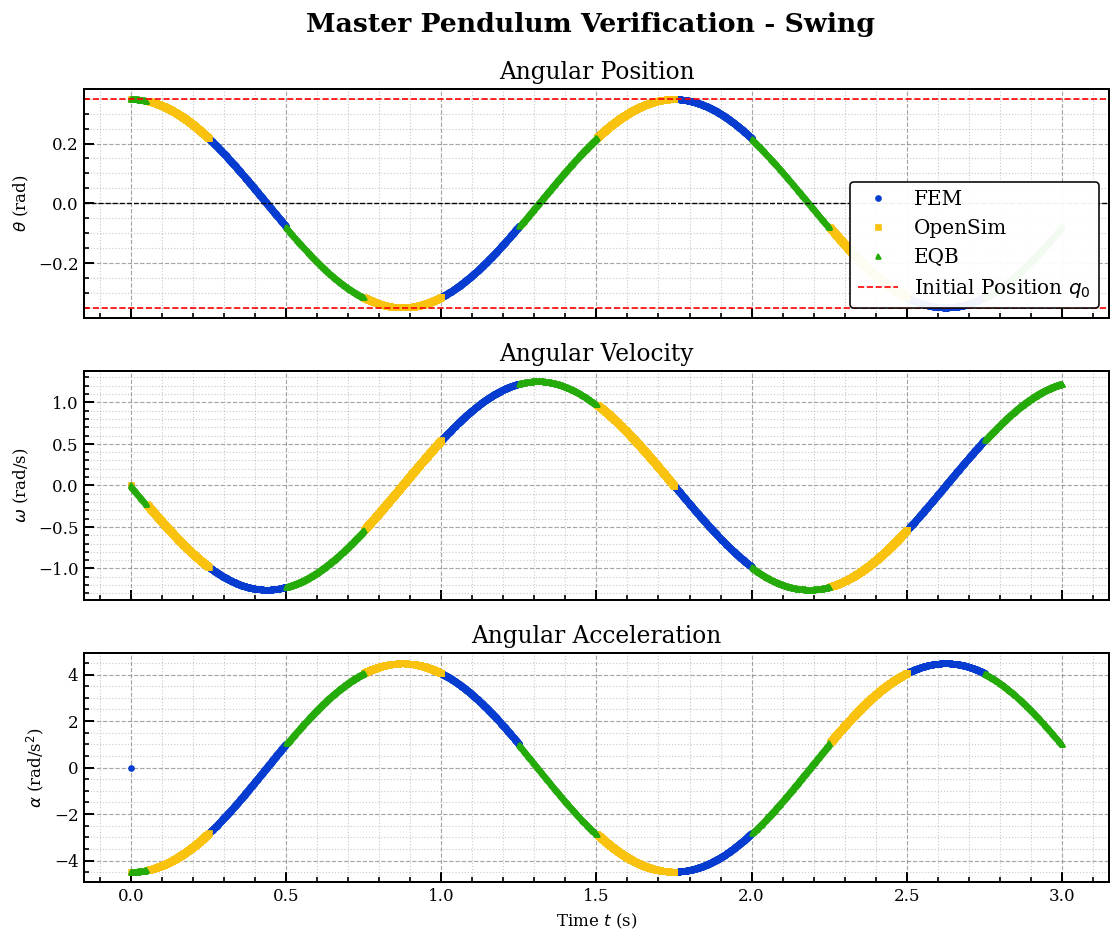

In [22]:
t_vals = {mode: [] for mode in pendulum.models.keys()}
torque_vals = {mode: [] for mode in pendulum.models.keys()}
alpha_vals = {mode: [] for mode in pendulum.models.keys()}
omega_vals = {mode: [] for mode in pendulum.models.keys()}
q_vals = {mode: [] for mode in pendulum.models.keys()}

for mode in pendulum.models.keys():
    t_vals[mode], res_dict = pendulum.models[mode].get_history_arrays()
    alpha_vals[mode] = res_dict['alpha']
    omega_vals[mode] = res_dict['omega']
    q_vals[mode]     = res_dict['q']

marker_size = 3
fem_style = {'color': "#063ccf", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'FEM'}
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'OpenSim'}  # Green
eqb_style = {'color': "#24aa09", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5, 'label': 'EQB'}  # Purple
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

fig.suptitle('Master Pendulum Verification - Swing', fontsize=16, fontweight='bold')

axs[0].set_title(r'Angular Position')
axs[0].plot(t_vals['FEM'], q_vals['FEM'], **fem_style)
axs[0].plot(t_vals['OpenSim'], q_vals['OpenSim'], **opensim_style)
axs[0].plot(t_vals['EQB'], q_vals['EQB'], **eqb_style)
axs[0].axhline(0, color='k', linestyle='--', linewidth=0.8)
axs[0].axhline(np.deg2rad(init_params.angular_position_deg), color='red', linestyle='--', label="Initial Position $q_0$", linewidth=1)
axs[0].axhline(-np.deg2rad(init_params.angular_position_deg), color='red', linestyle='--',linewidth=1)
axs[0].set_ylabel(r'$\theta$ (rad)')
axs[0].legend(loc='lower right')

axs[1].set_title(r'Angular Velocity')
axs[1].plot(t_vals['FEM'], omega_vals['FEM'], **fem_style)
axs[1].plot(t_vals['OpenSim'], omega_vals['OpenSim'], **opensim_style)
axs[1].plot(t_vals['EQB'], omega_vals['EQB'], **eqb_style)

axs[1].set_ylabel(r'$\omega$ (rad/s)')

axs[2].set_title(r'Angular Acceleration')
axs[2].plot(t_vals['FEM'], alpha_vals['FEM'], **fem_style)
axs[2].plot(t_vals['OpenSim'], alpha_vals['OpenSim'], **opensim_style)
axs[2].plot(t_vals['EQB'], alpha_vals['EQB'], **eqb_style)
axs[2].set_ylabel(r'$\alpha$ (rad/s$^2$)')
axs[2].set_xlabel(r'Time $t$ (s)')

for ax in axs:
    ax.minorticks_on()
    ax.grid(True, which='major', linestyle='--', alpha=0.7)
    ax.grid(True, which='minor', linestyle=':', alpha=0.4)


# adjust layout and add vertical space
plt.tight_layout(rect=[0, 0, 0.95, 0.95])
plt.subplots_adjust(top=0.9)
plt.savefig("../figures/StateSynchronization_swing.svg")
plt.show()